# Local registration with ICP

In the RGBD folder we have the first 400 images from one of the datasets from: [http://redwood-data.org/indoor_lidar_rgbd/download.html](http://redwood-data.org/indoor_lidar_rgbd/download.html)

In [10]:
import open3d as o3d
import matplotlib.pyplot as plt
import numpy as np
import copy
        
# Helper function to draw registrations (reccomended)
def draw_registrations(source, target, transformation = None, recolor = False):
    # Create deep copies to avoid modifying the original point clouds
    source_temp = copy.deepcopy(source)
    target_temp = copy.deepcopy(target)
    
    # If recolor is True, paint source Orange and target Blue/Cyan
    # This visual contrast helps assess the alignment quality.
    if(recolor):
        source_temp.paint_uniform_color([1, 0.706, 0])
        target_temp.paint_uniform_color([0, 0.651, 0.929])
    
    # Apply the transformation matrix to the source cloud if provided
    if(transformation is not None):
        source_temp.transform(transformation)
    
    # Render the geometries in a window
    o3d.visualization.draw_geometries([source_temp, target_temp])

## Creating point clouds from image data
Now we are going to try to create our own point clouds from RGB+depth images.
First, we load two RGBD images.

In [11]:
path = "C:/Users/peisz/OneDrive/Documents/Egyetem/DTU/3rd semester/PAS/Week 5/"
# Read in images. We have images 000000 - 0000400
# RGB-D data consists of a standard color image (RGB) and a depth map (D),
# where each pixel value represents the distance from the camera.
color_raw0 = o3d.io.read_image(path + "RGBD/color/000000.jpg")
depth_raw0 = o3d.io.read_image(path + "RGBD/depth/000000.png")

color_raw1 = o3d.io.read_image(path + "RGBD/color/000005.jpg")
depth_raw1 = o3d.io.read_image(path + "RGBD/depth/000005.png")

Create point clouds from rgb + depth images.

If you set `convert_rgb_to_intensity = False` you will retain the colors from the rgb image.

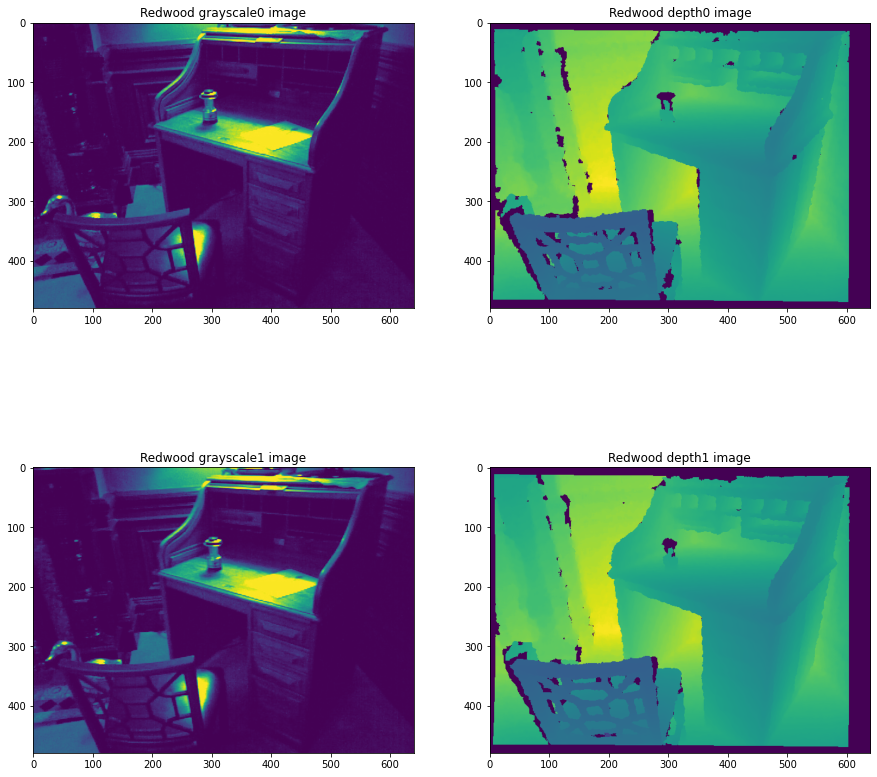

In [12]:
# Combine color and depth images into an RGBDImage object.
# convert_rgb_to_intensity=True: Converts the color image to grayscale intensity. 
# This is often sufficient for geometric processing and saves memory.
rgbd_image0 = o3d.geometry.RGBDImage.create_from_color_and_depth(
    color_raw0, 
    depth_raw0, 
    convert_rgb_to_intensity = True)

rgbd_image1 = o3d.geometry.RGBDImage.create_from_color_and_depth(
    color_raw1, 
    depth_raw1, 
    convert_rgb_to_intensity = True)

#show images
fig= plt.figure(figsize=(15,15))
plt.subplot(221)
plt.title('Redwood grayscale0 image')
plt.imshow(rgbd_image0.color)

plt.subplot(222)
plt.title('Redwood depth0 image')
plt.imshow(rgbd_image0.depth)

plt.subplot(223)
plt.title('Redwood grayscale1 image')
plt.imshow(rgbd_image1.color)

plt.subplot(224)
plt.title('Redwood depth1 image')
plt.imshow(rgbd_image1.depth)

plt.show()

## Images to point cloud
Now we create point clouds from the RGBD images we just loaded/created.


Here, we use `PinholeCameraIntrinsicParameters.PrimeSenseDefault` as default camera parameters. 

It has an image resolution of 640x480, focal length of ($f_x$, $f_y$) = (525.0, 525.0), and optical center ($c_x$, $c_y$) = (319.5, 239.5). 

An identity matrix is used as default extrinsic parameters. `pcd.transform` applies an up-down flip transformation on the point cloud for an improved visualization.


If execution becomes too slow you can downsample the point cloud.

In [13]:
# Camera parameters (Intrinsics)
# These parameters define how 3D points in the world map to 2D pixels in the image.
# We use a preset 'PrimeSenseDefault' which is common for Kinect/PrimeSense depth cameras.
camera = o3d.camera.PinholeCameraIntrinsic(
        o3d.camera.PinholeCameraIntrinsicParameters.PrimeSenseDefault)

# Create 3D Point Clouds from the 2D RGBD images using the camera intrinsics.
# This process "back-projects" pixels into 3D space.
# Z = depth_value / scale
# X = (u - cx) * Z / fx
# Y = (v - cy) * Z / fy
source = o3d.geometry.PointCloud.create_from_rgbd_image(
    rgbd_image0, camera)

target = o3d.geometry.PointCloud.create_from_rgbd_image(
    rgbd_image1, camera)

# Flip the point clouds.
# Open3D coordinate system might differ from the camera's native system.
# This matrix flips the Y and Z axes to orient the scene correctly for visualization (upright).
# [[1,  0,  0, 0],   (X -> X)
#  [0, -1,  0, 0],   (Y -> -Y)
#  [0,  0, -1, 0],   (Z -> -Z)
#  [0,  0,  0, 1]]
source.transform([[1, 0, 0, 0], [0, -1, 0, 0], [0, 0, -1, 0], [0, 0, 0, 1]])
target.transform([[1, 0, 0, 0], [0, -1, 0, 0], [0, 0, -1, 0], [0, 0, 0, 1]])

# Draw the point clouds before registration to see the initial misalignment.
draw_registrations(source, target, recolor=True)

### Evaluation of pointclouds

Before we can run ICP, we evaluate our source and target point clouds. This gives us a feeling if we need a better initial transformation or not
(from http://www.open3d.org/docs/latest/tutorial/Basic/icp_registration.html):

"The function `evaluate_registration` calculates two main metrics. 
- `fitness` measures the overlapping area (# of inlier correspondences / # of points in target). The higher the better. 
- `inlier_rmse` measures the RMSE of all inlier correspondences. The lower the better.

In [14]:
# Parameters for evaluation and ICP
# threshold: The max distance between two points to be considered a correspondence pair.
# Since the images are close in time (000000 vs 000005), 2cm (0.02m) is a reasonable threshold.
threshold = 0.02

# Initial transformation matrix (Identity matrix).
# We assume the camera hasn't moved much between frames, so we start with no rotation/translation.
trans_init = np.asarray([[1, 0, 0, 0], [0, 1, 0, 0], [0, 0, 1, 0], [0, 0, 0, 1]])

#Evaluate registration
print("Initial alignment")
evaluation = o3d.pipelines.registration.evaluate_registration(source, target, threshold, trans_init)
print(evaluation)

Initial alignment
RegistrationResult with fitness=9.176427e-01, inlier_rmse=9.789196e-03, and correspondence_set size of 240059
Access transformation to get result.


## ICP

Now try to call icp with your point clouds and your initial transformation.

Initially we use:
```Python
point_to_plane =  o3d.pipelines.registration.TransformationEstimationPointToPlane()
icp_result = o3d.pipelines.registration.registration_icp(
    source, target, threshold, trans_init,
    point_to_plane)
```

In [15]:
###
# ICP code here
###


# Estimate Normals
# Normal vectors are required for Point-to-Plane ICP.
# radius=0.05: Search radius (5cm) to find neighbors for normal estimation.
# max_nn=30: Max number of neighbors to consider.
source.estimate_normals(o3d.geometry.KDTreeSearchParamHybrid(radius=0.05, max_nn=30))
target.estimate_normals(o3d.geometry.KDTreeSearchParamHybrid(radius=0.05, max_nn=30))

# Define the Point-to-Plane Estimation method.
# Point-to-Plane is generally faster and more robust than Point-to-Point for geometric surfaces like rooms.
# It minimizes the perpendicular distance from a source point to the target plane.
point_to_plane = o3d.pipelines.registration.TransformationEstimationPointToPlane()

# Run Iterative Closest Point (ICP) registration.
# It iteratively refines the transformation 'trans_init' to minimize the distance between 
# corresponding points in 'source' and 'target' that are within 'threshold'.
icp_result = o3d.pipelines.registration.registration_icp(
    source, target, threshold, trans_init, point_to_plane)

# Visualize the result
# First with recoloring to distinctively see the overlap.
draw_registrations(source, target, icp_result.transformation, True)
# Then with original colors to see the seamless reconstruction.
draw_registrations(source, target, icp_result.transformation)

# Exersices

### A)
If you increase the amount of steps from the original image so from i.e. 000000.jpg<>000005.jpg to 00000.jpg<>000300.jpg, what happens?

In [16]:
# Load a frame that is much further away in time (Frame 300).
color_raw2 = o3d.io.read_image(path + "RGBD/color/000300.jpg")
depth_raw2 = o3d.io.read_image(path + "RGBD/depth/000300.png")

rgbd_image2 = o3d.geometry.RGBDImage.create_from_color_and_depth(
    color_raw2, 
    depth_raw2, 
    convert_rgb_to_intensity = True)

targetNew = o3d.geometry.PointCloud.create_from_rgbd_image(
    rgbd_image2, camera)
targetNew.transform([[1, 0, 0, 0], [0, -1, 0, 0], [0, 0, -1, 0], [0, 0, 0, 1]])

# Evaluate the initial alignment (Identity matrix).
# Since the camera moved significantly between frame 0 and 300, the overlap will be poor.
print("Initial alignment")
evaluation = o3d.pipelines.registration.evaluate_registration(source, targetNew, threshold, trans_init)
print(evaluation)

# Estimate normals for the new target
targetNew.estimate_normals(o3d.geometry.KDTreeSearchParamHybrid(radius=0.05, max_nn=30))

# Run ICP. 
# ICP is a "Local Registration" method. It only works if the initial alignment is somewhat close.
# Because the gap is too large, ICP will likely converge to a local minimum (bad alignment) or fail.
icp_resultNew = o3d.pipelines.registration.registration_icp(
    source, targetNew, threshold, trans_init, point_to_plane)

draw_registrations(source, targetNew, icp_resultNew.transformation, True)

Initial alignment
RegistrationResult with fitness=5.096635e-02, inlier_rmse=1.196329e-02, and correspondence_set size of 13333
Access transformation to get result.


### B)
Can you tweak the parameters `threshold` and `trans_init` to combat some of the ill effects that starts appearing?

In [17]:
# Tweak parameters to help ICP find the correct global minimum.
# Increase threshold: Allows looking for correspondences further away (0.2m = 20cm).
threshold = 0.2

# Provide a better initial guess (trans_init).
# Since we don't know the exact movement, this is tricky.
# Here we just try a slight scaling/rotation tweak, but ideally, you'd use a Global Registration (RANSAC) first
# to get a coarse alignment before refining with ICP.
trans_init = np.asarray([[1, 0, 0, 0], [0, 0.8, 0, 0], [0, 0, 0.9, 0], [0, 0, 0, 1]])

print("Initial alignment")
evaluation = o3d.pipelines.registration.evaluate_registration(source, target, threshold, trans_init)
print(evaluation)

icp_resultNew = o3d.pipelines.registration.registration_icp(
    source, targetNew, threshold, trans_init, point_to_plane)

draw_registrations(source, targetNew, icp_resultNew.transformation, True)

Initial alignment
RegistrationResult with fitness=9.721793e-01, inlier_rmse=9.911032e-02, and correspondence_set size of 254326
Access transformation to get result.


### C)
Again try to use 
```Python
point_to_plane =  o3d.pipelines.registration.TransformationEstimationPointToPlane()

reg_p2p = o3d.pipelines.registration.registration_icp(
    source, target, threshold, trans_init,
    point_to_plane)
```

This requires you to find the normals for each point cloud use:
```python
    source.estimate_normals(o3d.geometry.KDTreeSearchParamHybrid(radius=0.5,
                            max_nn=30),fast_normal_computation=True)
```
Compare the resulting translations of the two methods. Is one better than the other?

In [18]:
threshold = 0.02
trans_init = np.asarray([[1, 0, 0, 0], [0, 1, 0, 0], [0, 0, 1, 0], [0, 0, 0, 1]])

# Estimate normals with a much larger radius (0.5m vs 0.05m).
# This smooths out local noise but might lose fine detail.
# fast_normal_computation=True: Uses a non-iterative method to compute normals faster.
source.estimate_normals(o3d.geometry.KDTreeSearchParamHybrid(radius=0.5,
                        max_nn=30),fast_normal_computation=True)
target.estimate_normals(o3d.geometry.KDTreeSearchParamHybrid(radius=0.5,
                        max_nn=30),fast_normal_computation=True)

point_to_plane = o3d.pipelines.registration.TransformationEstimationPointToPlane()

# Run ICP Point-to-Plane
reg_p2p = o3d.pipelines.registration.registration_icp(
    source, target, threshold, trans_init,
    point_to_plane)

# Compare visualization:
# icp_result used smaller radius (0.05) normals.
# reg_p2p uses larger radius (0.5) normals.
# Usually, the smaller radius captures geometry better for close-up indoor scenes.
draw_registrations(source, target, icp_result.transformation, True)
draw_registrations(source, target, reg_p2p.transformation, True)

### D)
Extend this and try to see how much of the bedroom you can reconstruct from the RGB and depth images.
You can extend a point cloud by `new = source + target`. Remember to resample the point cloud after a view additions so it does not get too large: `down_source = source.voxel_down_sample(voxel_size=0.05)`

In [19]:
# Initialize the "Global" point cloud with the first frame
# We will iterate through a subset of images (e.g., every 5th frame) to speed up processing
# and cover more of the room without processing all 400 frames.
start_idx = 0
end_idx = 400 # The dataset has 400 images
step = 5

# Load the first frame (Frame 0) to start the sequence
color_0 = o3d.io.read_image(path + "RGBD/color/{:06d}.jpg".format(start_idx))
depth_0 = o3d.io.read_image(path + "RGBD/depth/{:06d}.png".format(start_idx))
rgbd_0 = o3d.geometry.RGBDImage.create_from_color_and_depth(color_0, depth_0, convert_rgb_to_intensity=False)

# Create the initial point cloud
# We assume 'camera' is defined from the previous cells (PrimeSenseDefault)
prev_pcd = o3d.geometry.PointCloud.create_from_rgbd_image(rgbd_0, camera)

# Flip it to be upright
prev_pcd.transform([[1, 0, 0, 0], [0, -1, 0, 0], [0, 0, -1, 0], [0, 0, 0, 1]])

# Estimate normals for the first frame (needed for Point-to-Plane ICP)
prev_pcd.estimate_normals(o3d.geometry.KDTreeSearchParamHybrid(radius=0.05, max_nn=30))

# This will hold our full reconstructed room
combined_pcd = copy.deepcopy(prev_pcd)

# Keep track of the global transformation matrix. 
# Initially, the camera is at the origin (Identity matrix).
current_global_transform = np.identity(4)

# Loop through the sequence
for i in range(start_idx + step, end_idx, step):
    print(f"Processing frame {i}...")
    
    # 1. Load the current RGBD image
    color = o3d.io.read_image(path + "RGBD/color/{:06d}.jpg".format(i))
    depth = o3d.io.read_image(path + "RGBD/depth/{:06d}.png".format(i))
    rgbd = o3d.geometry.RGBDImage.create_from_color_and_depth(color, depth, convert_rgb_to_intensity=False)
    
    # 2. Convert to Point Cloud
    curr_pcd = o3d.geometry.PointCloud.create_from_rgbd_image(rgbd, camera)
    curr_pcd.transform([[1, 0, 0, 0], [0, -1, 0, 0], [0, 0, -1, 0], [0, 0, 0, 1]])
    curr_pcd.estimate_normals(o3d.geometry.KDTreeSearchParamHybrid(radius=0.05, max_nn=30))
    
    # 3. Perform ICP Registration
    # We align the Current frame (source) to the Previous frame (target).
    # Since the frames are close in time, the movement is small, so Identity matrix is a decent initial guess.
    # We use Point-to-Plane as it is generally more accurate for sliding surfaces (walls/floors).
    reg_p2p = o3d.pipelines.registration.registration_icp(
        curr_pcd, prev_pcd, threshold, np.identity(4),
        o3d.pipelines.registration.TransformationEstimationPointToPlane())
    
    # 4. Update Global Transform
    # The transform 'reg_p2p.transformation' moves 'curr' to align with 'prev'.
    # To move 'curr' all the way to the Global start position, we multiply:
    # Global_Transform_New = Global_Transform_Old @ Local_Transform
    current_global_transform = current_global_transform @ reg_p2p.transformation
    
    # 5. Transform the current cloud to the global coordinate frame
    # We use deepcopy because we need 'curr_pcd' untransformed for the NEXT iteration's alignment
    curr_pcd_global = copy.deepcopy(curr_pcd)
    curr_pcd_global.transform(current_global_transform)
    
    # 6. Accumulate the points
    combined_pcd += curr_pcd_global
    
    # 7. Downsample
    # As the prompt suggests, we must downsample to prevent memory explosion.
    # 0.05 = 5cm voxel size.
    combined_pcd = combined_pcd.voxel_down_sample(voxel_size=0.05)
    
    # 8. Update 'prev_pcd' for the next iteration
    prev_pcd = curr_pcd

# Visualizing the final result
# We assume 'draw_registrations' is defined from previous cells, but simple draw_geometries works too.
o3d.visualization.draw_geometries([combined_pcd])

Processing frame 5...
Processing frame 10...
Processing frame 15...
Processing frame 20...
Processing frame 25...
Processing frame 30...
Processing frame 35...
Processing frame 40...
Processing frame 45...
Processing frame 50...
Processing frame 55...
Processing frame 60...
Processing frame 65...
Processing frame 70...
Processing frame 75...
Processing frame 80...
Processing frame 85...
Processing frame 90...
Processing frame 95...
Processing frame 100...
Processing frame 105...
Processing frame 110...
Processing frame 115...
Processing frame 120...
Processing frame 125...
Processing frame 130...
Processing frame 135...
Processing frame 140...
Processing frame 145...
Processing frame 150...
Processing frame 155...
Processing frame 160...
Processing frame 165...
Processing frame 170...
Processing frame 175...
Processing frame 180...
Processing frame 185...
Processing frame 190...
Processing frame 195...
Processing frame 200...
Processing frame 205...
Processing frame 210...
Processing f